In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

In [9]:
# Load the CSV file (replace 'your_file.csv' with your file name)
df_red = pd.read_csv("lab_red.csv")
df_yellow = pd.read_csv("lab_yellow.csv")
df_blue = pd.read_csv("lab_blue.csv")
df_green = pd.read_csv("lab_green.csv")
df_orange = pd.read_csv("lab_orange.csv")


# Load all CSVs
data_files = {
    "red": "lab_red.csv",
    "yellow": "lab_yellow.csv",
    "blue": "lab_blue.csv",
    "green": "lab_green.csv",
    "orange": "lab_orange.csv"
}


print(df_red.adc35_voltage.head(), df_yellow.adc35_voltage.head(), df_green.adc35_voltage.head(), df_blue.adc35_voltage.head(), df_orange.adc35_voltage.head(), data_files)

0    0.015
1    0.029
2    0.039
3    0.052
4    0.064
Name: adc35_voltage, dtype: float64 0    0.018
1    0.031
2    0.046
3    0.054
4    0.067
Name: adc35_voltage, dtype: float64 0    0.044
1    0.055
2    0.066
3    0.079
4    0.090
Name: adc35_voltage, dtype: float64 0    0.048
1    0.060
2    0.073
3    0.086
4    0.094
Name: adc35_voltage, dtype: float64 0    0.013
1    0.030
2    0.040
3    0.052
4    0.064
Name: adc35_voltage, dtype: float64 {'red': 'lab_red.csv', 'yellow': 'lab_yellow.csv', 'blue': 'lab_blue.csv', 'green': 'lab_green.csv', 'orange': 'lab_orange.csv'}


In [ ]:
10*((10000)/(10000+2000))


8.333333333333334

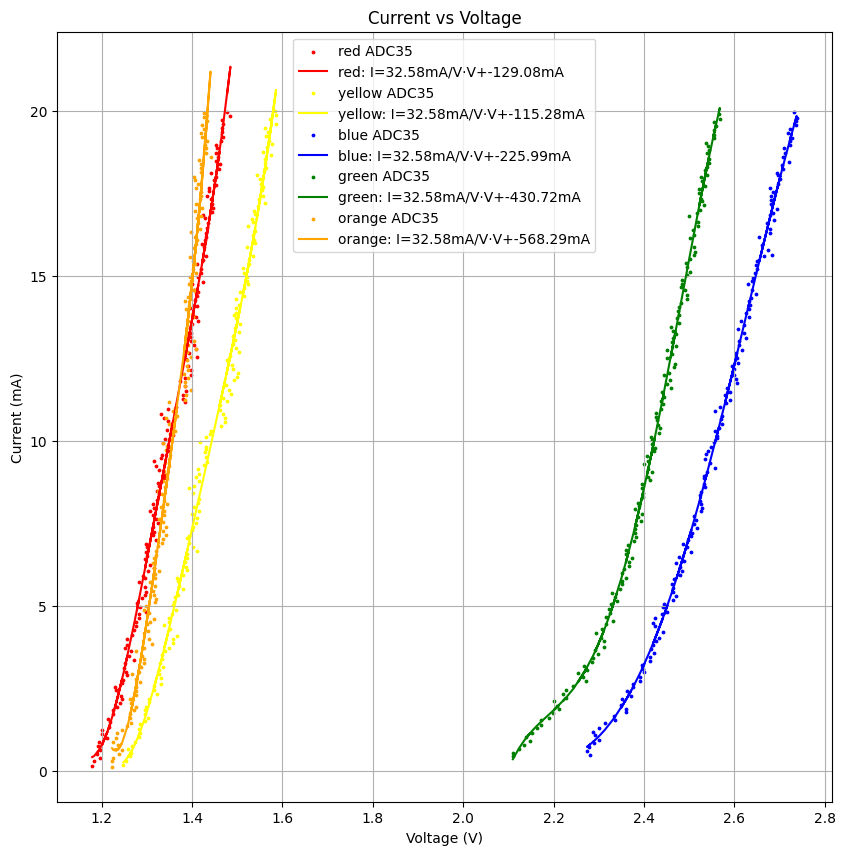

In [53]:
plt.figure(figsize=(10, 10))

for color, file in data_files.items():
    df = pd.read_csv(file)
    
    # Create current variables
    df['V_led']=df['adc34_voltage'] * ((10000+2000)/2000) - df['adc35_voltage']
    df['Iled']=df['adc35_voltage']/100

    df = df[df['Iled'] <= 0.02]

    a, b, c = np.polyfit(df['V_led'], df['Iled'], 2)

    df['fit_old'] = a * df['V_led']**2 + b * df['V_led'] + c

    p = np.poly1d(np.polyfit(df['V_led'], df['Iled'], 4))
    
    df['fit'] = p(df['V_led'])

    # Plot I vs V (using dac_voltage as V)
    plt.scatter(df['V_led'], df['Iled']*1000,
             label=f'{color} ADC35', color=color, s=3)
    
    plt.plot(df['V_led'], df['fit']*1000, 
             label=f'{color}: I={m*1000:.2f}mA/V·V+{b*1000:.2f}mA', color=color)
    


plt.xlabel('Voltage (V)')
plt.ylabel('Current (mA)')
plt.title('Current vs Voltage')
plt.legend()
plt.grid(True)

plt.show()

In [68]:
# Files
data_files = {
    "red": "lab_red.csv",
    "yellow": "lab_yellow.csv",
    "blue": "lab_blue.csv",
    "green": "lab_green.csv",
    "orange": "lab_orange.csv"
}

fig = go.Figure()

R = 100  # ohms
V1 = 10

for color, file in data_files.items():
    df = pd.read_csv(file)

    df['V_led']=df['adc34_voltage'] * ((10000+2000)/2000) - df['adc35_voltage']
    df['Iled']=df['adc35_voltage']/100

    df = df[df['Iled'] <= 0.02]

    p = np.poly1d(np.polyfit(df['V_led'], df['Iled'], 4))
    
    df['fit'] = p(df['V_led'])

    a, b, c = np.polyfit(df['V_led'], df['Iled'], 2)
    name=f'{color} fit: {a:.2e}V² + {b:.2e}V + {c:.2e}'

    # Add traces
    fig.add_trace(go.Scatter(
        x=df['V_led'],
        y=df['Iled']*1000,
        mode='markers',
        name=f'{color} ADC35',
        marker=dict(color=color, size=3)
    ))

    fig.add_trace(go.Scatter(
        x=df['V_led'],
        y=df['fit']*1000,
        mode='lines',
        name=f'{color}: {a:.3f}V² + {b:.3f}V + {c:.3f}',
        line=dict(color=color, dash='solid')
    ))

# Layout
fig.update_layout(
    title="Interactive Current vs Voltage",
    xaxis_title="Voltage (V)",
    yaxis_title="Current (mA)",
    template="plotly_white",
    width=1000,
    height=800
)

fig.show()

In [25]:
n = df["V_led"][:9]
print(n)

0    1.223
1    1.224
2    1.226
3    1.238
4    1.244
5    1.236
6    1.226
7    1.231
8    1.234
Name: V_led, dtype: float64
